# 🛍️ Online Retail Customer Segmentation & Sales Analysis

## 📌 Project Overview

This project analyses transactional data from an online retail business to understand **sales performance, customer purchasing behaviour and customer value**.

The analysis combines **Python, SQL and RFM customer segmentation** to transform raw transaction data into actionable business insights.

### 🎯 Project Objectives

The project aims to answer the following business questions:

1. How does revenue change over time?
2. Which products generate the most revenue?
3. Which countries contribute the most to overall sales?
4. Who are the company's highest-value customers?
5. How frequently do customers place orders and how much do they typically spend?
6. How can customers be segmented using **Recency, Frequency and Monetary (RFM) analysis**?
7. Which customer segments should the business prioritise for retention, loyalty and re-engagement strategies?

### 🛠️ Tools & Techniques

- **Python** — data cleaning, analysis and visualisation
- **Pandas & NumPy** — data manipulation
- **Matplotlib** — data visualisation
- **SQLite / SQL** — business queries and customer analysis
- **RFM Analysis** — customer-value segmentation
- **Google Colab** — development environment

### 📊 Analytical Workflow

**Data Loading → Data Quality Assessment → Data Cleaning → Exploratory Sales Analysis → SQL Analysis → RFM Customer Segmentation → Business Recommendations**

In [54]:
import os

print(os.listdir("/content"))


['.config', 'online_retail_data', 'repeat_customer_revenue.png', 'top_10_international_markets.png', 'rfm_segment_revenue.png', 'online+retail+ii.zip', 'top_10_products_revenue.png', 'monthly_revenue_trend.png', 'sample_data']


In [55]:
import zipfile
import os

zip_path = "/content/online+retail+ii.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/online_retail_data")

print("Files extracted successfully:")
print(os.listdir("/content/online_retail_data"))

Files extracted successfully:
['online_retail_II.xlsx']


## 2. Dataset Loading & Initial Inspection

The Online Retail II dataset contains transactional data from a UK-based online retailer.

Before performing any cleaning or analysis, the workbook is inspected to identify the available worksheets and ensure the data is loaded correctly.

In [56]:
# Inspect the Excel workbook

file_path = "/content/online_retail_data/online_retail_II.xlsx"

excel_file = pd.ExcelFile(file_path)

print("Available worksheets:")
print(excel_file.sheet_names)

Available worksheets:
['Year 2009-2010', 'Year 2010-2011']


In [57]:
# Load both worksheets

df_2009_2010 = pd.read_excel(
    file_path,
    sheet_name="Year 2009-2010"
)

df_2010_2011 = pd.read_excel(
    file_path,
    sheet_name="Year 2010-2011"
)

# Combine both years into one DataFrame

df = pd.concat(
    [df_2009_2010, df_2010_2011],
    ignore_index=True
)

print("Both worksheets loaded successfully.")
print("2009-2010 shape:", df_2009_2010.shape)
print("2010-2011 shape:", df_2010_2011.shape)
print("Combined dataset shape:", df.shape)

Both worksheets loaded successfully.
2009-2010 shape: (525461, 8)
2010-2011 shape: (541910, 8)
Combined dataset shape: (1067371, 8)


## 3. Initial Dataset Inspection

Before cleaning the data, the combined dataset is inspected to understand its structure, feature types and potential data-quality issues.

The inspection focuses on:

- Column names and data types
- Missing values
- Duplicate transactions
- Date coverage
- Invalid quantities or prices
- Cancelled transactions

These checks help determine the cleaning steps required before sales and customer analysis.

In [58]:
# Display the first five rows

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [59]:
# Inspect dataset structure and data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [60]:
# Check duplicate rows and missing values

print("Duplicate rows:", df.duplicated().sum())

print("\nMissing values by column:")
print(df.isnull().sum())

Duplicate rows: 34335

Missing values by column:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [61]:
# Check the transaction date range

print("Earliest transaction:", df["InvoiceDate"].min())
print("Latest transaction:", df["InvoiceDate"].max())

Earliest transaction: 2009-12-01 07:45:00
Latest transaction: 2011-12-09 12:50:00


### Data Quality Investigation

The initial inspection identified duplicate records and missing customer information.

Before removing records, additional checks are performed for cancelled transactions, non-positive quantities and non-positive prices. These records require careful treatment because they may represent returns, cancellations, adjustments or invalid transactions rather than genuine completed sales.

In [62]:
# Investigate cancelled and potentially invalid transactions

cancelled_orders = df["Invoice"].astype(str).str.startswith("C")

print("Cancelled transaction rows:", cancelled_orders.sum())
print("Rows with Quantity <= 0:", (df["Quantity"] <= 0).sum())
print("Rows with Price <= 0:", (df["Price"] <= 0).sum())

print("\nQuantity range:")
print("Minimum:", df["Quantity"].min())
print("Maximum:", df["Quantity"].max())

print("\nPrice range:")
print("Minimum:", df["Price"].min())
print("Maximum:", df["Price"].max())

print("\nUnique customers:", df["Customer ID"].nunique())
print("Unique countries:", df["Country"].nunique())

Cancelled transaction rows: 19494
Rows with Quantity <= 0: 22950
Rows with Price <= 0: 6207

Quantity range:
Minimum: -80995
Maximum: 80995

Price range:
Minimum: -53594.36
Maximum: 38970.0

Unique customers: 5942
Unique countries: 43


## 4. Data Cleaning

The raw dataset contains cancelled transactions, returns, duplicate records, missing customer identifiers and non-positive prices or quantities.

For the primary sales and customer analysis, the dataset is cleaned to represent completed positive-value transactions.

The following cleaning steps are applied:

- Remove duplicate transaction rows
- Remove cancelled invoices
- Retain transactions with quantities greater than zero
- Retain transactions with prices greater than zero
- Remove records without a Customer ID
- Remove records without a product description
- Convert Customer ID to integer format

Transactions without a Customer ID are excluded because they cannot be reliably assigned to an individual customer for customer-level or RFM analysis.

The original raw dataset is retained separately so that cancelled and returned transactions remain available for potential future analysis.

In [63]:
# Create a copy for cleaned sales analysis

sales_df = df.copy()

original_rows = len(sales_df)

# Remove duplicate rows
sales_df = sales_df.drop_duplicates()

# Remove cancelled invoices
sales_df = sales_df[
    ~sales_df["Invoice"].astype(str).str.startswith("C")
]

# Keep only positive quantities and prices
sales_df = sales_df[
    (sales_df["Quantity"] > 0) &
    (sales_df["Price"] > 0)
]

# Remove records without customer or product information
sales_df = sales_df.dropna(
    subset=["Customer ID", "Description"]
)

# Convert Customer ID to integer
sales_df["Customer ID"] = sales_df["Customer ID"].astype(int)

# Reset index
sales_df = sales_df.reset_index(drop=True)

print("Data cleaning complete.")
print("Original rows:", original_rows)
print("Cleaned rows:", len(sales_df))
print("Rows removed:", original_rows - len(sales_df))

print("\nMissing values remaining:")
print(sales_df.isnull().sum())

print("\nDuplicate rows remaining:", sales_df.duplicated().sum())
print("Cancelled invoices remaining:",
      sales_df["Invoice"].astype(str).str.startswith("C").sum())
print("Non-positive quantities remaining:",
      (sales_df["Quantity"] <= 0).sum())
print("Non-positive prices remaining:",
      (sales_df["Price"] <= 0).sum())

Data cleaning complete.
Original rows: 1067371
Cleaned rows: 779425
Rows removed: 287946

Missing values remaining:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

Duplicate rows remaining: 0
Cancelled invoices remaining: 0
Non-positive quantities remaining: 0
Non-positive prices remaining: 0


## 5. Sales Performance Analysis

Following data cleaning, the analysis begins by measuring the retailer's overall sales performance.

Revenue is calculated at transaction-line level by multiplying the quantity purchased by the unit price:

**Revenue = Quantity × Price**

Core business KPIs are then calculated to provide an overview of sales activity across the full analysis period.

In [64]:
# Calculate revenue for each transaction line

sales_df["Revenue"] = sales_df["Quantity"] * sales_df["Price"]

# Calculate core sales KPIs

total_revenue = sales_df["Revenue"].sum()
total_orders = sales_df["Invoice"].nunique()
total_customers = sales_df["Customer ID"].nunique()
total_products = sales_df["StockCode"].nunique()
total_countries = sales_df["Country"].nunique()
average_order_value = total_revenue / total_orders

print("SALES PERFORMANCE OVERVIEW")
print("-" * 35)
print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Unique Customers: {total_customers:,}")
print(f"Unique Products: {total_products:,}")
print(f"Countries Served: {total_countries:,}")
print(f"Average Order Value: £{average_order_value:,.2f}")

SALES PERFORMANCE OVERVIEW
-----------------------------------
Total Revenue: £17,374,804.27
Total Orders: 36,969
Unique Customers: 5,878
Unique Products: 4,631
Countries Served: 41
Average Order Value: £469.98


### 📌 Sales Performance Summary

Following data cleaning, the dataset contains **36,969 completed orders from 5,878 identifiable customers**, generating approximately **£17.37 million in revenue** across the analysis period.

The retailer sold **4,631 unique products** across **41 countries**, demonstrating a broad product range and international customer base.

The **average order value was approximately £469.98**, meaning that each completed invoice generated around £470 in revenue on average.

These figures establish the overall scale of the business. The next stages of the analysis investigate how this revenue changes over time and which products, countries and customers contribute most strongly to sales performance.

### Monthly Revenue Trends

Monthly revenue is analysed to identify changes in sales performance over time, including periods of strong growth, seasonal peaks and weaker trading months.

Understanding these patterns can support inventory planning, marketing campaigns and seasonal business decisions.

In [65]:
# Create month variable

sales_df["YearMonth"] = sales_df["InvoiceDate"].dt.to_period("M")

# Calculate monthly revenue

monthly_revenue = (
    sales_df.groupby("YearMonth")["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue["YearMonth"] = monthly_revenue["YearMonth"].astype(str)

# Identify highest and lowest revenue months

highest_month = monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmax()
]

lowest_month = monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmin()
]

print("MONTHLY REVENUE SUMMARY")
print("-" * 35)

print(
    f"Highest revenue month: {highest_month['YearMonth']} "
    f"(£{highest_month['Revenue']:,.2f})"
)

print(
    f"Lowest revenue month: {lowest_month['YearMonth']} "
    f"(£{lowest_month['Revenue']:,.2f})"
)

monthly_revenue

MONTHLY REVENUE SUMMARY
-----------------------------------
Highest revenue month: 2010-11 (£1,166,460.02)
Lowest revenue month: 2011-02 (£446,084.92)


,YearMonth,Revenue
0,2009-12,683504.010
1,2010-01,555802.672
2,2010-02,504558.956
3,2010-03,696978.471
4,2010-04,591982.002
5,2010-05,597833.380
6,2010-06,636371.130
7,2010-07,589736.170
8,2010-08,602224.600
9,2010-09,829013.951


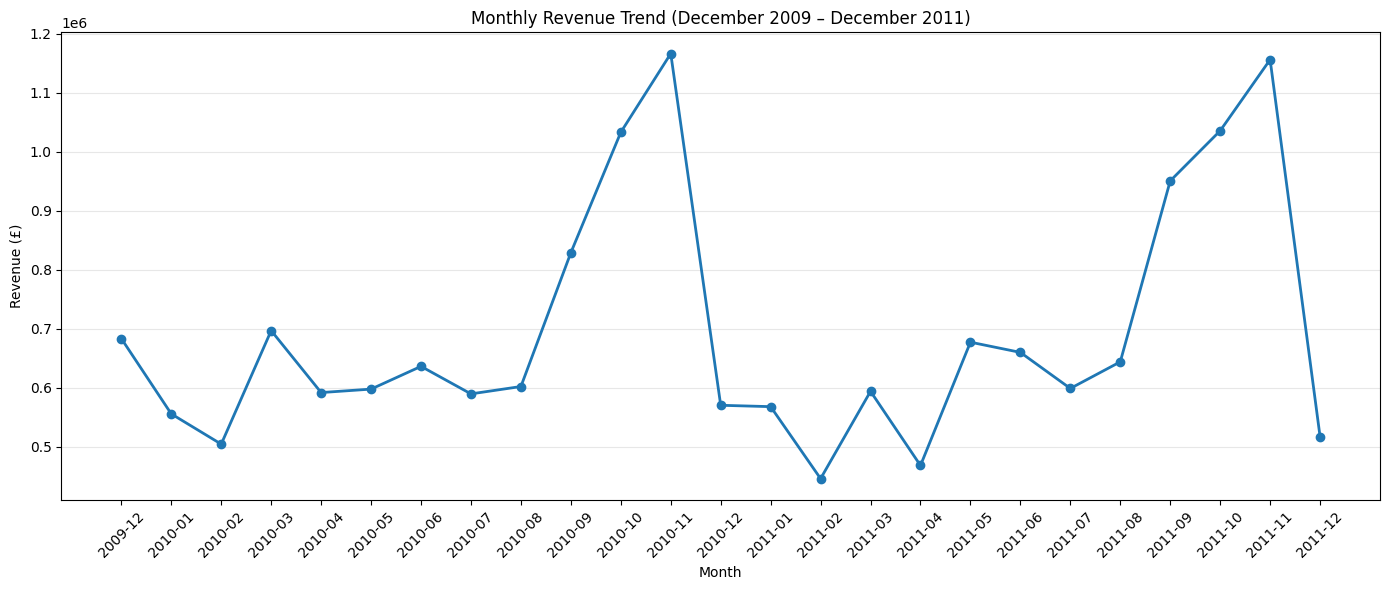

In [66]:
# Visualise monthly revenue

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue["YearMonth"],
    monthly_revenue["Revenue"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue Trend (December 2009 – December 2011)")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "monthly_revenue_trend.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 📌 Monthly Revenue Insights

Monthly sales demonstrate a clear seasonal pattern across the dataset.

Revenue increased substantially during the **September–November period in both 2010 and 2011**, suggesting that the final quarter of the year represents an important trading period for the retailer.

**November 2010 generated the highest monthly revenue at approximately £1.17 million.** November 2011 followed closely at approximately **£1.16 million**, demonstrating that the strong November performance was repeated across both years.

The lowest complete month was **February 2011**, generating approximately **£446,085** in revenue.

Revenue exceeded £1 million in both **October and November** during 2010 and 2011, reinforcing the presence of a recurring year-end sales peak.

The apparent decline in **December 2011 should not be interpreted as a full-month reduction in sales**, because the dataset ends on 9 December 2011 and therefore contains only a partial month.

### 💡 Business Implication

The recurring September–November increase suggests that the retailer could prepare for stronger year-end demand through earlier inventory planning, targeted seasonal marketing and sufficient operational capacity.

Lower-performing periods such as February may also provide opportunities for targeted promotions designed to stimulate demand outside the peak season.

### Product Performance

Product-level analysis is used to identify which items contribute most strongly to revenue.

Products are ranked by total revenue generated across completed transactions. This provides a clearer measure of commercial value than sales volume alone because it accounts for both the quantity sold and the price of each product.

In [67]:
# Calculate revenue by product

product_performance = (
    sales_df.groupby(["StockCode", "Description"])
    .agg(
        Units_Sold=("Quantity", "sum"),
        Revenue=("Revenue", "sum"),
        Orders=("Invoice", "nunique")
    )
    .reset_index()
)

# Rank products by revenue

top_products = (
    product_performance
    .sort_values("Revenue", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_products.index = top_products.index + 1

print("TOP 10 PRODUCTS BY REVENUE")
print("-" * 40)

top_products

TOP 10 PRODUCTS BY REVENUE
----------------------------------------


,StockCode,Description,Units_Sold,Revenue,Orders
1,22423,REGENCY CAKESTAND 3 TIER,24124,277656.25,3317
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,91757,247048.01,4888
3,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1
4,M,Manual,9384,151777.67,620
5,85099B,JUMBO BAG RED RETROSPOT,74224,134307.44,2612
6,POST,POSTAGE,5235,124648.04,1803
7,84879,ASSORTED COLOUR BIRD ORNAMENT,78234,124351.86,2652
8,47566,PARTY BUNTING,23460,103283.38,2077
9,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73,195
10,22086,PAPER CHAIN KIT 50'S CHRISTMAS,28380,76598.18,1691


#### Product Data Validation

The initial product ranking revealed that some stock codes represent operational charges or manual adjustments rather than physical merchandise.

For product-performance analysis, these non-merchandise records should be excluded so that the ranking reflects genuine products sold to customers.

The initial results also identified an unusually large transaction for **PAPER CRAFT, LITTLE BIRDIE**, where 80,995 units were recorded in a single order. Rather than automatically deleting this transaction from the cleaned sales dataset, it is retained but flagged as an extreme transaction that may disproportionately influence product-level revenue rankings.

In [68]:
# Identify common non-merchandise stock codes

non_product_codes = [
    "POST",      # Postage
    "M",         # Manual adjustments
    "DOT",       # Dotcom postage
    "BANK CHARGES",
    "AMAZONFEE"
]

# Create merchandise-only dataset for product analysis

product_sales_df = sales_df[
    ~sales_df["StockCode"].astype(str).str.upper().isin(non_product_codes)
].copy()

# Recalculate product performance

product_performance = (
    product_sales_df.groupby(["StockCode", "Description"])
    .agg(
        Units_Sold=("Quantity", "sum"),
        Revenue=("Revenue", "sum"),
        Orders=("Invoice", "nunique")
    )
    .reset_index()
)

top_products = (
    product_performance
    .sort_values("Revenue", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_products.index = top_products.index + 1

print("TOP 10 MERCHANDISE PRODUCTS BY REVENUE")
print("-" * 45)

top_products

TOP 10 MERCHANDISE PRODUCTS BY REVENUE
---------------------------------------------


,StockCode,Description,Units_Sold,Revenue,Orders
1,22423,REGENCY CAKESTAND 3 TIER,24124,277656.25,3317
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,91757,247048.01,4888
3,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1
4,85099B,JUMBO BAG RED RETROSPOT,74224,134307.44,2612
5,84879,ASSORTED COLOUR BIRD ORNAMENT,78234,124351.86,2652
6,47566,PARTY BUNTING,23460,103283.38,2077
7,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73,195
8,22086,PAPER CHAIN KIT 50'S CHRISTMAS,28380,76598.18,1691
9,79321,CHILLI LIGHTS,14843,69084.30,922
10,85099F,JUMBO BAG STRAWBERRY,35842,64127.77,1514


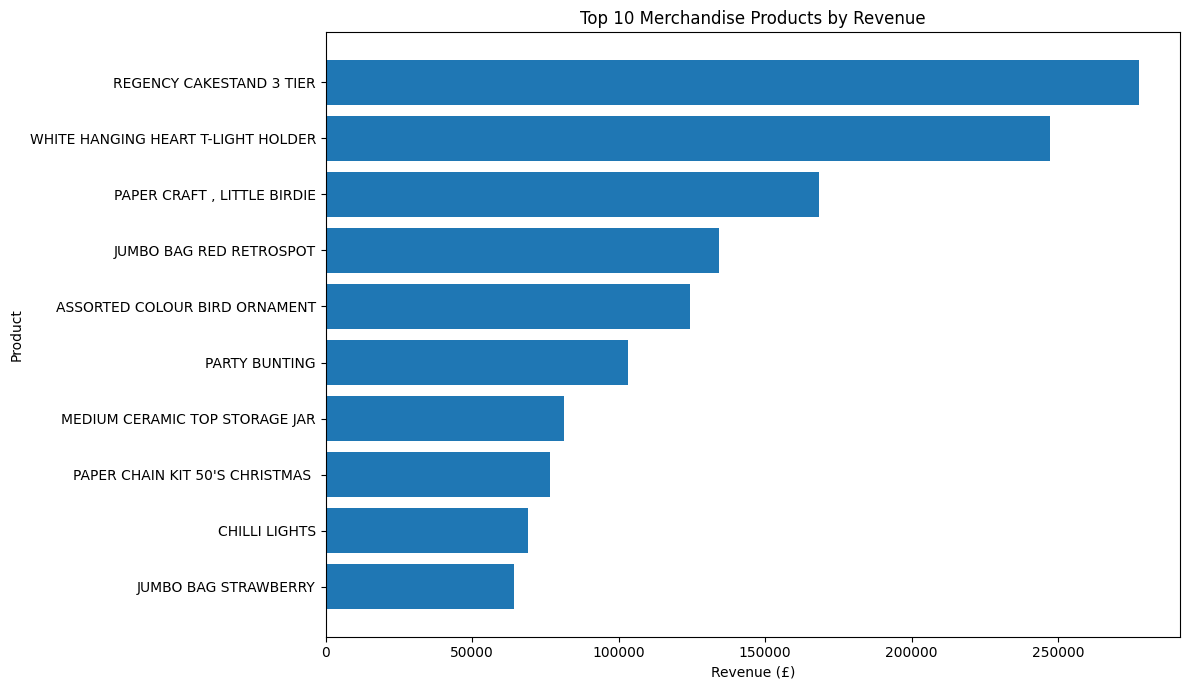

In [69]:
# Visualise top 10 merchandise products by revenue

top_products_chart = top_products.sort_values(
    "Revenue",
    ascending=True
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_products_chart["Description"],
    top_products_chart["Revenue"]
)

plt.title("Top 10 Merchandise Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig(
    "top_10_products_revenue.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 📌 Product Performance Insights

**REGENCY CAKESTAND 3 TIER** was the highest-revenue merchandise product, generating approximately **£277,656** across 3,317 orders.

**WHITE HANGING HEART T-LIGHT HOLDER** ranked second by revenue at approximately **£247,048**, while appearing in 4,888 orders — the highest order frequency among the top 10 products.

Several products combined high sales volume with strong revenue contribution, including **JUMBO BAG RED RETROSPOT**, **ASSORTED COLOUR BIRD ORNAMENT** and **PARTY BUNTING**.

One notable outlier was **PAPER CRAFT, LITTLE BIRDIE**, which generated approximately **£168,470 from a single order of 80,995 units**. Because this transaction is unusually large compared with typical product purchases, it should be interpreted cautiously rather than treated as evidence of consistently strong customer demand.

Operational stock codes such as postage and manual adjustments were excluded from the merchandise ranking so that the analysis reflects genuine product performance.

### 💡 Business Implication

Products that combine strong revenue with purchases across many different orders may represent particularly valuable core inventory and could be prioritised for stock availability and marketing.

Extreme one-off purchases should be monitored separately because they can substantially affect product rankings without necessarily representing recurring demand.

### Geographic Sales Performance

Revenue is analysed by country to understand the retailer's geographic sales distribution and identify its strongest international markets.

Because the business is UK-based, the analysis first measures the United Kingdom's contribution to total revenue before examining non-UK markets separately. This prevents the dominant domestic market from obscuring differences between international customers.

In [70]:
# Calculate revenue by country

country_performance = (
    sales_df.groupby("Country")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("Invoice", "nunique"),
        Customers=("Customer ID", "nunique")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

# Calculate each country's share of total revenue

country_performance["Revenue_Share_%"] = (
    country_performance["Revenue"] / total_revenue * 100
)

top_countries = country_performance.head(10).copy()

print("TOP 10 COUNTRIES BY REVENUE")
print("-" * 40)

top_countries

TOP 10 COUNTRIES BY REVENUE
----------------------------------------


,Country,Revenue,Orders,Customers,Revenue_Share_%
38,United Kingdom,1.438923e+07,33541,5350,82.816673
10,EIRE,6.165705e+05,567,5,3.548647
24,Netherlands,5.540381e+05,228,22,3.188744
14,Germany,4.250197e+05,789,107,2.446184
13,France,3.487690e+05,614,95,2.007326
0,Australia,1.692835e+05,95,15,0.974304
32,Spain,1.083325e+05,154,41,0.623503
34,Switzerland,1.000619e+05,90,22,0.575903
33,Sweden,9.151582e+04,104,19,0.526716
9,Denmark,6.858069e+04,43,12,0.394713


### 📌 Geographic Sales Insights

The United Kingdom is by far the retailer's largest market, generating approximately **82.82% of total revenue**.

Because domestic sales dominate the dataset, international markets are analysed separately to provide a clearer view of overseas performance.

Among non-UK markets, **EIRE, the Netherlands, Germany and France** generate the strongest revenue contributions.

In [71]:
# Analyse the strongest international markets

international_markets = (
    country_performance[
        country_performance["Country"] != "United Kingdom"
    ]
    .head(10)
    .copy()
)

international_markets_display = international_markets.copy()

international_markets_display["Revenue"] = (
    international_markets_display["Revenue"].round(2)
)

international_markets_display["Revenue_Share_%"] = (
    international_markets_display["Revenue_Share_%"].round(2)
)

print("TOP 10 INTERNATIONAL MARKETS BY REVENUE")
print("-" * 45)

international_markets_display

TOP 10 INTERNATIONAL MARKETS BY REVENUE
---------------------------------------------


,Country,Revenue,Orders,Customers,Revenue_Share_%
10,EIRE,616570.54,567,5,3.55
24,Netherlands,554038.09,228,22,3.19
14,Germany,425019.71,789,107,2.45
13,France,348768.96,614,95,2.01
0,Australia,169283.46,95,15,0.97
32,Spain,108332.49,154,41,0.62
34,Switzerland,100061.94,90,22,0.58
33,Sweden,91515.82,104,19,0.53
9,Denmark,68580.69,43,12,0.39
3,Belgium,65387.82,149,29,0.38


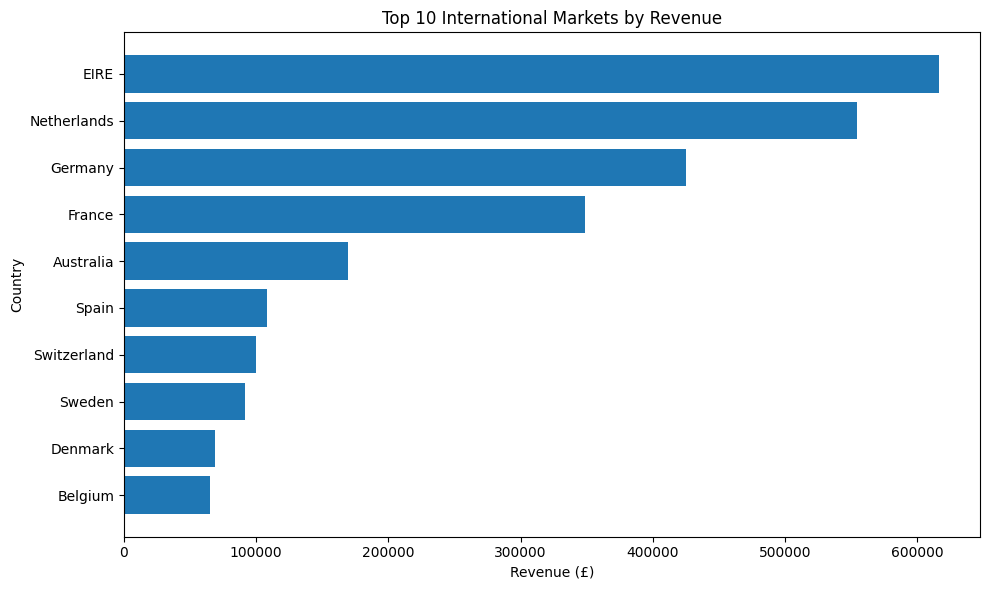

In [72]:
# Visualise top international markets by revenue

international_chart = international_markets.sort_values(
    "Revenue",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    international_chart["Country"],
    international_chart["Revenue"]
)

plt.title("Top 10 International Markets by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.tight_layout()

plt.savefig(
    "top_10_international_markets.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 💡 Business Implication

The retailer is heavily dependent on the UK market, which contributes more than four-fifths of total revenue.

Among international markets, **EIRE and the Netherlands** generate particularly strong revenue despite serving far fewer customers and orders than the UK.

Germany and France also represent important overseas markets with comparatively strong order activity.

This geographic concentration suggests two strategic considerations:

- Protecting performance in the UK remains critical because of its dominant contribution to total sales.
- Strong international markets could be investigated further for targeted expansion, localisation and customer-retention opportunities.

Revenue alone should not be used to determine market attractiveness. Customer counts, order frequency and average order value should also be considered when assessing international growth opportunities.

## 6. Customer Behaviour Analysis

Customer-level analysis is used to understand differences in purchasing behaviour and identify customers who contribute the greatest value to the business.

For each customer, the analysis measures:

- **Total Revenue** — total amount spent across completed transactions
- **Number of Orders** — number of unique purchases made
- **Average Order Value** — average revenue generated per order
- **Total Units Purchased** — total quantity of products purchased

These metrics provide a foundation for identifying high-value customers and later performing RFM customer segmentation.

In [73]:
# Create customer-level performance metrics

customer_performance = (
    sales_df.groupby("Customer ID")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Orders=("Invoice", "nunique"),
        Total_Units=("Quantity", "sum")
    )
    .reset_index()
)

# Calculate average order value for each customer

customer_performance["Average_Order_Value"] = (
    customer_performance["Total_Revenue"] /
    customer_performance["Orders"]
)

# Rank customers by total revenue

top_customers = (
    customer_performance
    .sort_values("Total_Revenue", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_customers.index = top_customers.index + 1

print("TOP 10 CUSTOMERS BY TOTAL REVENUE")
print("-" * 45)

top_customers

TOP 10 CUSTOMERS BY TOTAL REVENUE
---------------------------------------------


,Customer ID,Total_Revenue,Orders,Total_Units,Average_Order_Value
1,18102,580987.04,145,181645,4006.807172
2,14646,528602.52,151,367193,3500.678940
3,14156,313437.62,156,164325,2009.215513
4,14911,291420.81,398,147972,732.213090
5,17450,244784.25,51,83914,4799.691176
6,13694,195640.69,143,188201,1368.116713
7,17511,172132.87,60,117174,2868.881167
8,16446,168472.50,2,80997,84236.250000
9,16684,147142.77,55,104810,2675.323091
10,12415,144458.37,28,91447,5159.227500


### Customer Revenue Concentration

The highest-value customers are analysed to determine how concentrated revenue is across the customer base.

This helps distinguish between a business with broadly distributed customer value and one that depends heavily on a relatively small number of high-spending customers.

Extreme customer values are interpreted carefully because unusually large one-off purchases can substantially influence revenue rankings.

In [74]:
# Rank all customers by total revenue

customer_ranked = customer_performance.sort_values(
    "Total_Revenue",
    ascending=False
).reset_index(drop=True)

# Calculate cumulative revenue share

customer_ranked["Cumulative_Revenue"] = (
    customer_ranked["Total_Revenue"].cumsum()
)

customer_ranked["Cumulative_Revenue_Share_%"] = (
    customer_ranked["Cumulative_Revenue"] /
    customer_ranked["Total_Revenue"].sum() * 100
)

# Calculate top-customer concentration

top_10_revenue_share = (
    customer_ranked.head(10)["Total_Revenue"].sum() /
    customer_ranked["Total_Revenue"].sum() * 100
)

top_100_revenue_share = (
    customer_ranked.head(100)["Total_Revenue"].sum() /
    customer_ranked["Total_Revenue"].sum() * 100
)

print("CUSTOMER REVENUE CONCENTRATION")
print("-" * 40)
print(f"Top 10 customers' revenue share: {top_10_revenue_share:.2f}%")
print(f"Top 100 customers' revenue share: {top_100_revenue_share:.2f}%")

print("\nTypical Customer Behaviour")
print("-" * 40)
print(
    f"Median customer revenue: "
    f"£{customer_performance['Total_Revenue'].median():,.2f}"
)
print(
    f"Median number of orders: "
    f"{customer_performance['Orders'].median():.0f}"
)
print(
    f"Median average order value: "
    f"£{customer_performance['Average_Order_Value'].median():,.2f}"
)

CUSTOMER REVENUE CONCENTRATION
----------------------------------------
Top 10 customers' revenue share: 16.04%
Top 100 customers' revenue share: 37.55%

Typical Customer Behaviour
----------------------------------------
Median customer revenue: £867.74
Median number of orders: 3
Median average order value: £279.24


### 📌 Customer Behaviour Insights

Customer spending is unevenly distributed across the customer base.

The **top 10 customers generate approximately 16.04% of total customer revenue**, while the **top 100 customers contribute approximately 37.55%**. This demonstrates that a relatively small group of customers represents a substantial proportion of business value.

However, typical customer behaviour is considerably more modest. The median customer:

- Generated approximately **£867.74 in total revenue**
- Placed **3 orders**
- Had an average order value of approximately **£279.24**

This contrasts sharply with the retailer's highest-value customers, several of whom generated more than £100,000 in revenue across the analysis period.

One extreme example is Customer 16446, whose unusually high value is driven by only two orders and is associated with the previously identified large-volume transaction. This customer should therefore be interpreted cautiously rather than treated as a typical high-value repeat customer.

### 💡 Business Implication

The concentration of revenue among high-value customers highlights the importance of customer retention. Losing even a relatively small number of major customers could have a meaningful effect on revenue.

At the same time, the large difference between typical and high-value customers suggests an opportunity to identify customers with the potential to move into higher-value groups through targeted retention, loyalty and personalised marketing strategies.

This makes customer segmentation particularly valuable for the business.

## 7. SQL Business Analysis

Alongside the Python analysis, SQL is used to answer key business questions directly from the cleaned transactional dataset.

The cleaned sales data is loaded into an SQLite database, allowing SQL queries to be used for aggregation, filtering, ranking and customer analysis.

This section demonstrates how the same retail data can be analysed using relational database techniques commonly used by data analysts.

In [75]:
# Create an SQLite database connection

conn = sqlite3.connect(":memory:")

# Prepare a SQL-friendly copy of the cleaned dataset

sql_sales = sales_df.copy()

sql_sales["InvoiceDate"] = (
    sql_sales["InvoiceDate"].astype(str)
)

sql_sales["YearMonth"] = (
    sql_sales["YearMonth"].astype(str)
)

# Load cleaned data into SQLite

sql_sales.to_sql(
    "sales",
    conn,
    index=False,
    if_exists="replace"
)

print("Cleaned sales data loaded into SQLite successfully.")

# Verify the number of records

query = """
SELECT COUNT(*) AS total_rows
FROM sales;
"""

pd.read_sql_query(query, conn)

Cleaned sales data loaded into SQLite successfully.


,total_rows
0,779425


### SQL Query 1 — Monthly Revenue Ranking

This query calculates monthly revenue and ranks each month from highest to lowest sales performance using a SQL window function.

It demonstrates aggregation, date grouping and the `RANK()` function.

In [76]:
# SQL Query 1: Rank months by revenue

query = """
WITH monthly_sales AS (
    SELECT
        YearMonth,
        ROUND(SUM(Revenue), 2) AS monthly_revenue
    FROM sales
    GROUP BY YearMonth
)

SELECT
    YearMonth,
    monthly_revenue,
    RANK() OVER (
        ORDER BY monthly_revenue DESC
    ) AS revenue_rank
FROM monthly_sales
ORDER BY revenue_rank;
"""

sql_monthly_ranking = pd.read_sql_query(query, conn)

sql_monthly_ranking.head(10)

,YearMonth,monthly_revenue,revenue_rank
0,2010-11,1166460.02,1
1,2011-11,1156205.61,2
2,2011-10,1035642.45,3
3,2010-10,1033112.01,4
4,2011-09,950690.20,5
5,2010-09,829013.95,6
6,2010-03,696978.47,7
7,2009-12,683504.01,8
8,2011-05,677355.15,9
9,2011-06,660046.05,10


### SQL Query 2 — International Market Performance

This query compares non-UK markets using total revenue, order volume and customer count.

It demonstrates SQL aggregation, filtering and ranking while helping identify overseas markets that contribute meaningful commercial value.

In [77]:
# SQL Query 2: Rank international markets

query = """
SELECT
    Country,
    ROUND(SUM(Revenue), 2) AS total_revenue,
    COUNT(DISTINCT Invoice) AS total_orders,
    COUNT(DISTINCT "Customer ID") AS unique_customers,
    ROUND(
        SUM(Revenue) / COUNT(DISTINCT Invoice),
        2
    ) AS average_order_value
FROM sales
WHERE Country <> 'United Kingdom'
GROUP BY Country
ORDER BY total_revenue DESC
LIMIT 10;
"""

sql_international_markets = pd.read_sql_query(query, conn)

sql_international_markets

,Country,total_revenue,total_orders,unique_customers,average_order_value
0,EIRE,616570.54,567,5,1087.43
1,Netherlands,554038.09,228,22,2429.99
2,Germany,425019.71,789,107,538.68
3,France,348768.96,614,95,568.03
4,Australia,169283.46,95,15,1781.93
5,Spain,108332.49,154,41,703.46
6,Switzerland,100061.94,90,22,1111.80
7,Sweden,91515.82,104,19,879.96
8,Denmark,68580.69,43,12,1594.90
9,Belgium,65387.82,149,29,438.84


### 📌 International Market Insights

International markets display very different purchasing patterns.

**EIRE** generated the highest non-UK revenue at approximately **£616,571**, but this revenue came from only **5 unique customers**, indicating a highly concentrated customer base.

The **Netherlands** generated approximately **£554,038** from 228 orders, with an average order value of approximately **£2,429.99** — considerably higher than Germany and France.

By comparison:

- **Germany** generated approximately £425,020 across 789 orders and 107 customers.
- **France** generated approximately £348,769 across 614 orders and 95 customers.
- **Australia** generated approximately £169,283 with an average order value of approximately £1,781.93.

These results demonstrate why market performance should not be assessed using revenue alone. Order frequency, customer count and average order value provide additional context about the structure and stability of each market.

### 💡 Business Implication

Markets such as EIRE and the Netherlands generate high revenue from relatively small customer bases, which may create greater dependency on individual customers.

Germany and France appear more diversified, with revenue spread across a larger number of customers and orders.

A balanced international strategy could therefore consider both **revenue opportunity and customer concentration risk** when prioritising markets for growth.

### SQL Query 3 — High-Value Customer Ranking

This query aggregates customer-level purchasing behaviour and ranks customers by total revenue using a Common Table Expression and SQL window function.

It demonstrates how SQL can be used to identify strategically important customers based on revenue, order frequency and average order value.

In [78]:
# SQL Query 3: Rank high-value customers

query = """
WITH customer_value AS (
    SELECT
        "Customer ID" AS customer_id,
        ROUND(SUM(Revenue), 2) AS total_revenue,
        COUNT(DISTINCT Invoice) AS total_orders,
        ROUND(
            SUM(Revenue) / COUNT(DISTINCT Invoice),
            2
        ) AS average_order_value
    FROM sales
    GROUP BY "Customer ID"
)

SELECT
    customer_id,
    total_revenue,
    total_orders,
    average_order_value,
    RANK() OVER (
        ORDER BY total_revenue DESC
    ) AS customer_rank
FROM customer_value
ORDER BY customer_rank
LIMIT 10;
"""

sql_top_customers = pd.read_sql_query(query, conn)

sql_top_customers

,customer_id,total_revenue,total_orders,average_order_value,customer_rank
0,18102,580987.04,145,4006.81,1
1,14646,528602.52,151,3500.68,2
2,14156,313437.62,156,2009.22,3
3,14911,291420.81,398,732.21,4
4,17450,244784.25,51,4799.69,5
5,13694,195640.69,143,1368.12,6
6,17511,172132.87,60,2868.88,7
7,16446,168472.50,2,84236.25,8
8,16684,147142.77,55,2675.32,9
9,12415,144458.37,28,5159.23,10


### 📌 High-Value Customer Insights

The SQL ranking confirms that a small group of customers contributes substantial revenue to the business.

**Customer 18102** ranked first, generating approximately **£580,987** across 145 orders, followed by Customer 14646 with approximately **£528,603** across 151 orders.

Several top customers combine high revenue with frequent repeat purchasing, making them strategically important from a retention perspective.

Customer 16446 is a notable exception. This customer generated approximately **£168,473 from only two orders**, resulting in an unusually high average order value. This aligns with the previously identified extreme high-volume transaction and should therefore be treated as an outlier rather than typical high-value repeat behaviour.

Overall, the SQL analysis demonstrates how aggregation, Common Table Expressions and window functions can be used to identify and rank commercially important customers.

## SQL Summary

The SQL analysis was used to:

- Rank monthly revenue using a window function
- Compare international market performance
- Analyse average order value across countries
- Aggregate customer-level purchasing behaviour
- Rank high-value customers
- Apply Common Table Expressions (CTEs)
- Use the `RANK()` window function

The SQL findings were consistent with the Python analysis and provided additional context around customer concentration, international market behaviour and high-value customer activity.

The next stage applies **RFM customer segmentation** to classify customers based on recency, purchase frequency and monetary value.

## 8. RFM Customer Segmentation

RFM analysis is used to segment customers according to their purchasing behaviour.

RFM measures three dimensions of customer value:

- **Recency (R)** — how recently a customer made their last purchase
- **Frequency (F)** — how many unique orders the customer placed
- **Monetary (M)** — how much revenue the customer generated

Customers who purchased recently, order frequently and spend more are generally considered more valuable and engaged.

For this analysis, the reference date is set to **one day after the final transaction date in the dataset**. This allows recency to be measured consistently as the number of days since each customer's most recent purchase.

In [79]:
# Set reference date to one day after the final transaction

reference_date = sales_df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Final transaction date:", sales_df["InvoiceDate"].max())
print("RFM reference date:", reference_date)

# Calculate RFM metrics for each customer

rfm = (
    sales_df.groupby("Customer ID")
    .agg(
        Recency=(
            "InvoiceDate",
            lambda x: (reference_date - x.max()).days
        ),
        Frequency=("Invoice", "nunique"),
        Monetary=("Revenue", "sum")
    )
    .reset_index()
)

print("\nRFM dataset shape:", rfm.shape)

rfm.head(10)

Final transaction date: 2011-12-09 12:50:00
RFM reference date: 2011-12-10 12:50:00

RFM dataset shape: (5878, 4)


,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,4921.53
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40
5,12351,375,1,300.93
6,12352,36,10,2849.84
7,12353,204,2,406.76
8,12354,232,1,1079.40
9,12355,214,2,947.61


### RFM Distribution Analysis

Before assigning RFM scores, the distribution of Recency, Frequency and Monetary values is examined.

Customer purchasing behaviour is often highly skewed, with a relatively small number of customers making substantially more purchases or generating considerably more revenue than the typical customer.

Examining the distributions helps ensure that the segmentation method reflects the structure of the customer base rather than applying arbitrary thresholds.

In [80]:
# Examine RFM summary statistics

rfm_summary = rfm[
    ["Recency", "Frequency", "Monetary"]
].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)

print("RFM SUMMARY STATISTICS")
print("-" * 40)

rfm_summary

RFM SUMMARY STATISTICS
----------------------------------------


,Recency,Frequency,Monetary
count,5878.00,5878.00,5878.00
mean,201.33,6.29,2955.90
std,209.34,13.01,14440.85
min,1.00,1.00,2.95
25%,26.00,1.00,342.28
50%,96.00,3.00,867.74
75%,380.00,7.00,2248.30
90%,535.00,13.00,5465.74
95%,625.00,21.00,9374.23
99%,726.00,46.00,29205.90


### RFM Scoring Method

Customers are assigned scores from **1 to 4** for each RFM dimension using quartile-based ranking.

The scoring direction reflects the meaning of each metric:

- **Recency:** Lower values are better because they indicate a more recent purchase. The most recent customers receive a score of 4.
- **Frequency:** Higher values are better because they indicate more frequent purchasing. The most frequent customers receive a score of 4.
- **Monetary:** Higher values are better because they indicate greater customer spending. The highest-spending customers receive a score of 4.

The RFM distributions are highly skewed. For example, the median customer placed 3 orders and generated £867.74, while the maximum values reached 398 orders and £580,987.04.

Quartile-based scoring reduces the influence of these extreme values and evaluates customers relative to the overall customer base.

In [81]:
# Assign quartile-based RFM scores

# rank(method="first") prevents duplicate values from causing qcut errors

rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    4,
    labels=[4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

# Create combined RFM score

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

# Create overall numeric score

rfm["RFM_Total"] = (
    rfm["R_Score"] +
    rfm["F_Score"] +
    rfm["M_Score"]
)

print("RFM scoring complete.")
print("\nScore distributions:")

print("\nRecency:")
print(rfm["R_Score"].value_counts().sort_index())

print("\nFrequency:")
print(rfm["F_Score"].value_counts().sort_index())

print("\nMonetary:")
print(rfm["M_Score"].value_counts().sort_index())

rfm.head(10)

RFM scoring complete.

Score distributions:

Recency:
R_Score
1    1470
2    1469
3    1469
4    1470
Name: count, dtype: int64

Frequency:
F_Score
1    1470
2    1469
3    1469
4    1470
Name: count, dtype: int64

Monetary:
M_Score
1    1470
2    1469
3    1469
4    1470
Name: count, dtype: int64


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,12346,326,12,77556.46,2,4,4,244,10
1,12347,2,8,4921.53,4,4,4,444,12
2,12348,75,5,2019.40,3,3,3,333,9
3,12349,19,4,4428.69,4,3,4,434,11
4,12350,310,1,334.40,2,1,1,211,4
5,12351,375,1,300.93,2,1,1,211,4
6,12352,36,10,2849.84,3,4,4,344,11
7,12353,204,2,406.76,2,2,2,222,6
8,12354,232,1,1079.40,2,1,3,213,6
9,12355,214,2,947.61,2,2,3,223,7


### Customer Segment Classification

RFM scores are translated into customer segments that can be used for marketing and retention decisions.

The segmentation primarily considers **Recency and Frequency**, while Monetary value is retained to measure the financial importance of each group.

The segments represent different stages of the customer relationship:

- **Champions** — recent and frequent customers
- **Loyal Customers** — frequent customers with strong ongoing engagement
- **Potential Loyalists** — relatively recent customers with developing purchase frequency
- **New Customers** — very recent customers with limited purchase history
- **Promising** — recent customers who may require further engagement
- **Needs Attention** — customers showing declining engagement
- **At Risk** — previously engaged customers who have not purchased recently
- **Hibernating** — infrequent customers with low recent activity
- **Lost** — customers with the weakest recency and frequency

In [82]:
# Assign customer segments based on Recency and Frequency scores

def assign_segment(row):
    r = row["R_Score"]
    f = row["F_Score"]

    if r == 4 and f == 4:
        return "Champions"

    elif r >= 3 and f == 4:
        return "Loyal Customers"

    elif r >= 3 and f == 3:
        return "Potential Loyalists"

    elif r == 4 and f == 1:
        return "New Customers"

    elif r == 4 and f == 2:
        return "Promising"

    elif r == 3 and f <= 2:
        return "Needs Attention"

    elif r <= 2 and f >= 3:
        return "At Risk"

    elif r == 2 and f <= 2:
        return "Hibernating"

    else:
        return "Lost"


rfm["Segment"] = rfm.apply(assign_segment, axis=1)

# Summarise segment sizes

segment_counts = (
    rfm["Segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = ["Segment", "Customers"]

segment_counts["Percentage"] = (
    segment_counts["Customers"] / len(rfm) * 100
).round(2)

print("CUSTOMER SEGMENT DISTRIBUTION")
print("-" * 40)

segment_counts

CUSTOMER SEGMENT DISTRIBUTION
----------------------------------------


,Segment,Customers,Percentage
0,Lost,1238,21.06
1,At Risk,888,15.11
2,Potential Loyalists,831,14.14
3,Hibernating,813,13.83
4,Champions,758,12.90
5,Needs Attention,567,9.65
6,Loyal Customers,462,7.86
7,Promising,231,3.93
8,New Customers,90,1.53


### Segment Value Analysis

Customer segment size alone does not indicate its commercial importance.

To understand the value of each RFM segment, the analysis compares:

- Number of customers
- Total revenue generated
- Share of customer revenue
- Average revenue per customer
- Average purchase frequency
- Average recency

This helps identify which customer groups contribute the greatest financial value and which groups may present retention or re-engagement opportunities.

In [83]:
# Calculate performance by customer segment

segment_performance = (
    rfm.groupby("Segment")
    .agg(
        Customers=("Customer ID", "count"),
        Total_Revenue=("Monetary", "sum"),
        Avg_Revenue_Per_Customer=("Monetary", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Recency=("Recency", "mean")
    )
    .reset_index()
)

# Calculate revenue share

segment_performance["Revenue_Share_%"] = (
    segment_performance["Total_Revenue"] /
    segment_performance["Total_Revenue"].sum() * 100
)

# Round values for readability

segment_performance[
    [
        "Total_Revenue",
        "Avg_Revenue_Per_Customer",
        "Avg_Frequency",
        "Avg_Recency",
        "Revenue_Share_%"
    ]
] = segment_performance[
    [
        "Total_Revenue",
        "Avg_Revenue_Per_Customer",
        "Avg_Frequency",
        "Avg_Recency",
        "Revenue_Share_%"
    ]
].round(2)

# Rank segments by revenue

segment_performance = (
    segment_performance
    .sort_values("Total_Revenue", ascending=False)
    .reset_index(drop=True)
)

print("RFM SEGMENT PERFORMANCE")
print("-" * 40)

segment_performance

RFM SEGMENT PERFORMANCE
----------------------------------------


,Segment,Customers,Total_Revenue,Avg_Revenue_Per_Customer,Avg_Frequency,Avg_Recency,Revenue_Share_%
0,Champions,758,9505240.54,12539.90,22.36,10.38,54.71
1,Loyal Customers,462,2389151.93,5171.32,12.42,50.65,13.75
2,At Risk,888,2192696.67,2469.25,6.54,275.49,12.62
3,Potential Loyalists,831,1407472.99,1693.71,4.63,35.48,8.10
4,Lost,1238,590221.90,476.75,1.37,523.88,3.40
5,Hibernating,813,530005.09,651.91,1.66,238.20,3.05
6,Needs Attention,567,387232.19,682.95,1.71,55.76,2.23
7,Promising,231,342857.16,1484.23,2.25,12.65,1.97
8,New Customers,90,29925.78,332.51,1.00,14.38,0.17


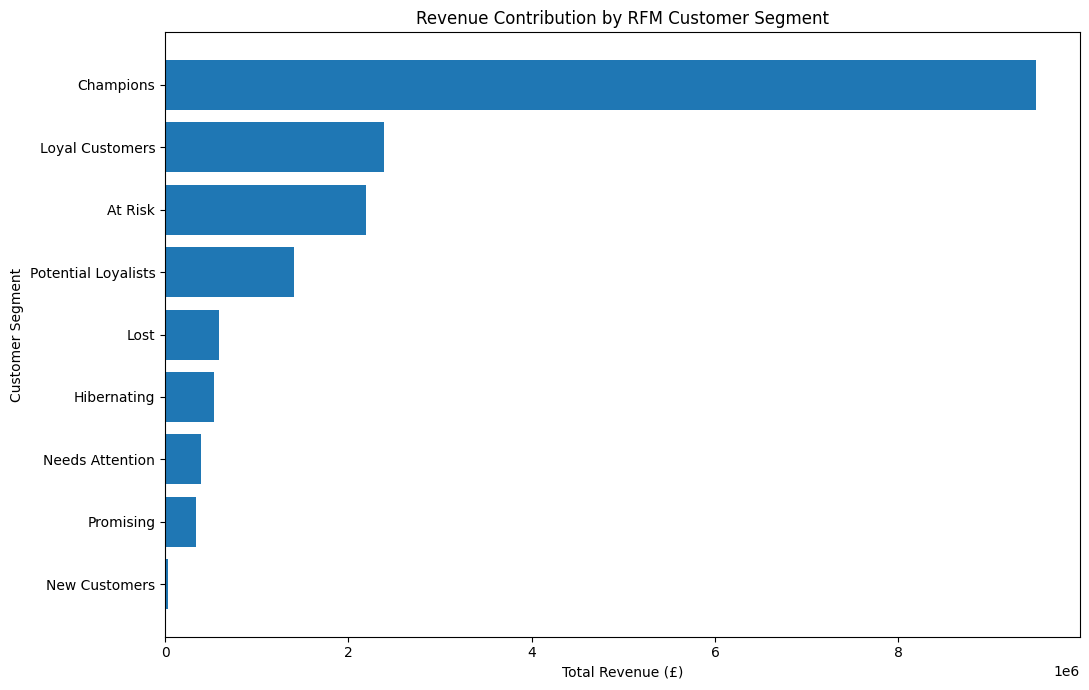

In [84]:
# Visualise revenue generated by each RFM segment

segment_chart = segment_performance.sort_values(
    "Total_Revenue",
    ascending=True
)

plt.figure(figsize=(11, 7))

plt.barh(
    segment_chart["Segment"],
    segment_chart["Total_Revenue"]
)

plt.title("Revenue Contribution by RFM Customer Segment")
plt.xlabel("Total Revenue (£)")
plt.ylabel("Customer Segment")

plt.tight_layout()

plt.savefig(
    "rfm_segment_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 📌 RFM Segmentation Insights

The RFM analysis reveals substantial differences in commercial value across customer segments.

**Champions are the retailer's most valuable customer group.** Although only 758 customers are classified as Champions, they generate approximately **£9.51 million**, representing **54.71% of total customer revenue**. Champions purchase very frequently, averaging 22.36 orders, and made their most recent purchase approximately 10 days ago on average.

**Loyal Customers** contribute a further **£2.39 million (13.75%)** of revenue. Together, Champions and Loyal Customers therefore generate approximately **68.46% of total customer revenue**, highlighting the importance of retaining highly engaged customers.

The **At Risk** segment represents a particularly important retention opportunity. These 888 customers generate approximately **£2.19 million (12.62%)** of revenue and average 6.54 orders, indicating meaningful historical purchasing activity. However, their average recency of approximately 275 days suggests that they have not purchased for a considerable period.

**Potential Loyalists** represent 831 customers and contribute approximately **£1.41 million (8.10%)** of revenue. Their relatively recent purchasing activity and developing purchase frequency suggest potential to become more valuable repeat customers.

The **Lost** segment is the largest by customer count, containing 1,238 customers (21.06%), but contributes only **3.40% of revenue**. These customers have an average recency of approximately 524 days and relatively low purchase frequency.

### 💡 Business Recommendations

The RFM segmentation suggests different strategies should be applied to different customer groups:

- **Champions:** Prioritise retention through VIP benefits, early product access, personalised recommendations and loyalty rewards.
- **Loyal Customers:** Encourage continued engagement through loyalty programmes, cross-selling and personalised offers.
- **At Risk:** Prioritise targeted win-back campaigns because this group has historically generated substantial revenue but has become inactive.
- **Potential Loyalists:** Encourage repeat purchases through targeted recommendations, incentives and loyalty-programme enrolment.
- **New & Promising Customers:** Focus on onboarding and second-purchase incentives to develop longer-term relationships.
- **Hibernating & Lost Customers:** Use lower-cost reactivation campaigns and prioritise customers with stronger historical value rather than applying expensive retention strategies to the entire group.

Overall, the analysis indicates that customer retention should be a major strategic priority. A relatively small proportion of highly engaged customers generates most of the retailer's revenue, while the At Risk segment represents a significant pool of historically valuable customers that may be recoverable through targeted re-engagement.

## 9. Repeat Customer Analysis

Repeat purchasing is analysed to understand the retailer's ability to generate ongoing customer relationships.

Customers are classified as:

- **One-Time Customers** — customers who completed exactly one order
- **Repeat Customers** — customers who completed two or more orders

The repeat customer rate provides an additional measure of customer engagement and complements the RFM segmentation by showing how much of the customer base returns after an initial purchase.

In [85]:
# Classify customers by repeat purchasing behaviour

customer_repeat = (
    sales_df.groupby("Customer ID")
    .agg(
        Orders=("Invoice", "nunique"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
)

customer_repeat["Customer_Type"] = np.where(
    customer_repeat["Orders"] > 1,
    "Repeat Customer",
    "One-Time Customer"
)

# Summarise customer behaviour

repeat_summary = (
    customer_repeat.groupby("Customer_Type")
    .agg(
        Customers=("Customer ID", "count"),
        Total_Revenue=("Revenue", "sum")
    )
    .reset_index()
)

repeat_summary["Customer_Share_%"] = (
    repeat_summary["Customers"] /
    repeat_summary["Customers"].sum() * 100
)

repeat_summary["Revenue_Share_%"] = (
    repeat_summary["Total_Revenue"] /
    repeat_summary["Total_Revenue"].sum() * 100
)

repeat_summary[
    ["Total_Revenue", "Customer_Share_%", "Revenue_Share_%"]
] = repeat_summary[
    ["Total_Revenue", "Customer_Share_%", "Revenue_Share_%"]
].round(2)

print("REPEAT CUSTOMER ANALYSIS")
print("-" * 40)

repeat_summary

REPEAT CUSTOMER ANALYSIS
----------------------------------------


,Customer_Type,Customers,Total_Revenue,Customer_Share_%,Revenue_Share_%
0,One-Time Customer,1623,560272.56,27.61,3.22
1,Repeat Customer,4255,16814531.71,72.39,96.78


### 📌 Repeat Customer Insights

Repeat customers are responsible for the overwhelming majority of the retailer's revenue.

Of the 5,878 customers analysed:

- **4,255 (72.39%) are repeat customers**
- **1,623 (27.61%) are one-time customers**

Repeat customers generated approximately **£16.81 million**, representing **96.78% of total customer revenue**.

In comparison, one-time customers generated approximately **£560,273**, accounting for only **3.22% of revenue**.

This demonstrates that repeat purchasing is a major driver of the retailer's financial performance. Although more than one-quarter of customers purchased only once, almost all revenue was generated by customers who returned for additional purchases.

### 💡 Business Implication

Customer retention should be a major commercial priority.

The business could focus on converting first-time buyers into repeat customers through post-purchase communication, personalised product recommendations, second-purchase incentives and loyalty programmes.

These findings also support the RFM analysis, where Champions and Loyal Customers were shown to generate a disproportionately large share of revenue.

Together, the results indicate that increasing repeat purchasing and retaining existing high-value customers may offer greater commercial value than focusing exclusively on acquiring new customers.

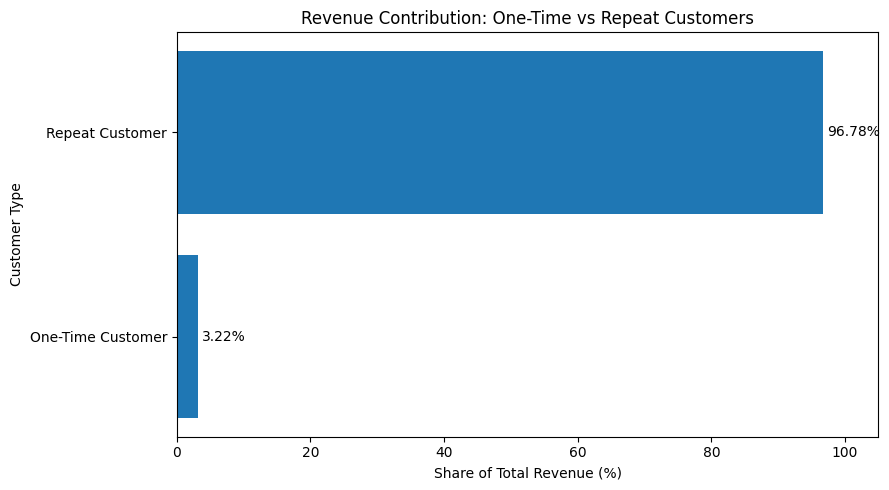

In [86]:
# Visualise revenue share by customer type

repeat_chart = repeat_summary.sort_values(
    "Revenue_Share_%",
    ascending=True
)

plt.figure(figsize=(9, 5))

bars = plt.barh(
    repeat_chart["Customer_Type"],
    repeat_chart["Revenue_Share_%"]
)

plt.title("Revenue Contribution: One-Time vs Repeat Customers")
plt.xlabel("Share of Total Revenue (%)")
plt.ylabel("Customer Type")

# Add percentage labels
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}%",
        va="center"
    )

plt.xlim(0, 105)

plt.tight_layout()

plt.savefig(
    "repeat_customer_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 10. Executive Summary & Business Recommendations

## Executive Summary

This project analysed more than **1.06 million transaction records** from an online retailer covering December 2009 to December 2011. After data cleaning, **779,425 completed transaction records** from **5,878 identifiable customers** were retained for sales and customer analysis.

The cleaned dataset generated approximately **£17.37 million in revenue from 36,969 completed orders**, with an average order value of approximately **£469.98**.

### Key Findings

**1. Sales demonstrate strong seasonality**

Revenue increased substantially during September–November in both complete trading years. **November 2010 was the highest-revenue month at approximately £1.17 million**, followed closely by November 2011 at approximately £1.16 million.

This recurring year-end increase indicates a strong seasonal sales pattern and suggests that inventory, marketing and operational planning should account for increased demand during the final quarter.

**2. Revenue is heavily concentrated in the UK**

The United Kingdom generated approximately **82.82% of total revenue**, making it the retailer's dominant market.

Internationally, EIRE, the Netherlands, Germany and France generated the strongest revenue. However, market structures differed substantially. EIRE generated high revenue from only five identifiable customers, while Germany and France had broader customer bases.

**3. A relatively small customer group generates most revenue**

RFM segmentation identified **758 Champions**, representing approximately **12.90% of customers**, yet this segment generated approximately **54.71% of customer revenue**.

Champions and Loyal Customers together generated approximately **68.46% of revenue**, demonstrating the commercial importance of retaining highly engaged customers.

**4. The At Risk segment represents a major retention opportunity**

There were **888 At Risk customers**, representing approximately **15.11% of the customer base**.

Despite their reduced recent activity, these customers generated approximately **£2.19 million historically**, or **12.62% of customer revenue**. Their previous purchasing behaviour suggests that targeted win-back campaigns could potentially recover valuable customers.

**5. Repeat customers drive almost all revenue**

Repeat customers represented **72.39% of customers** but generated approximately **96.78% of total customer revenue**.

One-time customers represented 27.61% of the customer base but generated only 3.22% of revenue, demonstrating that repeat purchasing is a major driver of commercial performance.

**6. Product performance requires careful interpretation**

REGENCY CAKESTAND 3 TIER and WHITE HANGING HEART T-LIGHT HOLDER were among the strongest merchandise products by revenue.

The analysis also identified unusually large individual transactions and operational stock codes. These were investigated separately to prevent non-merchandise records or extreme transactions from being interpreted as normal product demand.

## Business Recommendations

Based on the analysis, the retailer could:

1. **Prioritise customer retention** by providing loyalty rewards, personalised recommendations and VIP benefits to Champions and Loyal Customers.

2. **Develop targeted win-back campaigns** for At Risk customers, particularly those with historically high spending or purchase frequency.

3. **Convert first-time buyers into repeat customers** through second-purchase incentives, post-purchase communication and personalised product recommendations.

4. **Prepare for seasonal demand earlier**, particularly ahead of the September–November sales increase, through inventory planning and targeted marketing.

5. **Protect the core UK market while evaluating international growth opportunities**, particularly in markets demonstrating high order values or strong customer activity.

6. **Monitor customer and transaction outliers separately** so that unusually large purchases do not distort standard performance reporting.

Overall, the analysis indicates that **customer retention, repeat purchasing and high-value customer management are central to the retailer's commercial performance**.

## 11. Limitations

Several limitations should be considered when interpreting the results:

- The dataset covers a historical period from December 2009 to December 2011, so the findings describe customer behaviour during that period and should not be interpreted as current retail trends.

- December 2011 is incomplete because the final recorded transaction occurred on 9 December 2011. Therefore, December 2011 revenue should not be directly compared with complete months.

- Transactions without Customer IDs were excluded from customer-level analysis because they could not be reliably associated with individual customers.

- Cancelled transactions, returns, duplicates and non-positive sales records were excluded from the primary completed-sales analysis. Returns and cancellations could be investigated separately in future analysis.

- Some unusually large transactions were identified. These records were retained where there was insufficient evidence to classify them as erroneous, but they were highlighted when they materially affected interpretation.

- RFM segmentation uses relative quartile-based scoring. Customer segment classifications therefore reflect purchasing behaviour within this dataset rather than universal customer-value thresholds.

- The dataset does not contain information such as marketing activity, acquisition channels, product costs or customer demographics. Therefore, profitability, campaign effectiveness and demographic drivers cannot be directly assessed.

## 12. Skills Demonstrated

This project demonstrates practical data-analysis skills across the full analytical workflow:

**Python**
- Pandas
- NumPy
- Data cleaning and transformation
- GroupBy aggregation
- Datetime analysis
- Customer-level feature engineering
- RFM segmentation

**SQL**
- SQLite
- SELECT, WHERE and GROUP BY
- Aggregate functions
- DISTINCT
- Common Table Expressions (CTEs)
- Window functions
- RANK()
- Customer and market-level analysis

**Data Visualisation**
- Matplotlib
- Time-series visualisation
- Product-performance charts
- Geographic market analysis
- Customer-segment visualisation
- Revenue-contribution analysis

**Business Analysis**
- KPI development
- Revenue analysis
- Seasonal trend analysis
- Product performance
- Customer concentration
- International market analysis
- Customer segmentation
- Retention analysis
- Business recommendations

The project demonstrates the ability to transform a large raw transactional dataset into structured, actionable business insights using **Python and SQL**.